# Reprodução do modelo isobárico — Square Dalitz (0, 1): $B^{\pm}\to\pi^{\pm}\pi^+\pi^-$

Este notebook é o benchmark signal-only da análise LHCb publicada em [Phys. Rev. D 101, 012006](https://cds.cern.ch/record/2689374/files/1909.05212.pdf).

O objetivo inicial é avaliar os coeficientes cartesianos publicados e calcular as fit fractions por carga e as assimetrias $A_{CP}$. A reprodução estatística do ajuste experimental exige os eventos de dados da análise; este notebook valida a álgebra de amplitudes e a normalização do fitter.

Cópia de `paper_isobar_benchmark.ipynb` com integração em Square Dalitz: `normalization_method="square-dalitz"`, `normalization_pair=(0, 1)`. Essa escolha se aplica aos modelos do benchmark e do toy closure.


## Convenções

Para cada componente, usamos a convenção da Tabela XXI:

$$c_q=(x+q\,\delta x)+i(y+q\,\delta y),\qquad q=+1\;(B^+),\;q=-1\;(B^-).$$

A contribuição $\rho(770)^0-\omega(782)$ é agrupada incluindo o termo de interferência entre os dois componentes.

Orientação angular: `pair=(2, 0)` usa a partícula 3 para definir o ângulo com a bachelor 2, como `LauKinematics::calcHelicities` para o par 1,3. A simetrização gera o par 3,2 com a mesma orientação. Inverter essa ordem muda o sinal das ondas ímpares relativamente às pares.

In [1]:
import sys
from pathlib import Path

# Make the notebook work from the repository or from notebooks/benchmark.
for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "src" / "dalitzplotfitter").is_dir():
        sys.path.insert(0, str(candidate / "src"))
        break

import numpy as np
import pandas as pd

from dalitzplotfitter import (
    DecayChannel, DecayModel, PipiKKRescattering,
    RealImag, RelativisticBreitWigner, Resonance, RhoOmegaMixing,
    SigmaPole, enable_x64, ZemachP
)

enable_x64()

In [2]:
# O notebook é autocontido: não depende de um módulo Python externo.
# Massas/larguras em GeV. A fonte dos números está documentada na célula seguinte.
RESCATTERING_CONVENTION = "laura"  # "paper" reproduz a expressão impressa
PAPER_MASS_WIDTHS = {
    "rho770": (0.7708, 0.1534),       # ajuste isobárico, Tabela XX
    "omega782": (0.78265, 0.00849),   # Laura++/PDG
    "f2_1270": (1.256, 0.1867),      # ajuste isobárico,
    "rho1450": (1.465, 0.400),        # Laura++/PDG
    "rho3_1690": (1.686, 0.186),      # Laura++/PDG
    "sigma": (0.563, 0.350),          # polo ajustado, Tabela XXII
}
COEFFICIENTS = {
    "rho770": (1.000, 0.000, -0.003, 0.000),
    "omega782": (0.091, -0.007, 0.000, -0.022),
    "f2_1270": (0.291, 0.204, -0.002, -0.179),
    "rho1450": (-0.223, 0.191, 0.031, 0.068),
    "rho3_1690": (0.073, -0.045, 0.044, -0.013),
    "rescattering": (0.142, -0.040, -0.047, -0.027),
    "sigma": (-0.485, 0.284, 0.231, 0.270),
}
PUBLISHED_FRACTIONS = {
    "+": {"rho770_omega782": 57.9, "f2_1270": 5.1, "rho1450": 6.2, "rho3_1690": 1.0, "rescattering": 0.8, "sigma": 22.2},
    "-": {"rho770_omega782": 53.3, "f2_1270": 12.6, "rho1450": 4.3, "rho3_1690": 0.1, "rescattering": 2.0, "sigma": 27.9},
}
PUBLISHED_ACP = {"rho770": 0.7, "omega782": -4.8, "f2_1270": 46.8, "rho1450": -12.9, "rho3_1690": -80.1, "rescattering": 44.7, "sigma": 16.0}

def coefficient(name, charge):
    x, y, dx, dy = COEFFICIENTS[name]
    return complex(x + charge * dx, y + charge * dy)

def components(charge):
    c = {name: coefficient(name, charge) for name in COEFFICIENTS}
    rho_mass, rho_width = PAPER_MASS_WIDTHS["rho770"]
    omega_mass, omega_width = PAPER_MASS_WIDTHS["omega782"]
    f2_mass, f2_width = PAPER_MASS_WIDTHS["f2_1270"]
    rho1450_mass, rho1450_width = PAPER_MASS_WIDTHS["rho1450"]
    rho3_mass, rho3_width = PAPER_MASS_WIDTHS["rho3_1690"]
    sigma_mass, sigma_width = PAPER_MASS_WIDTHS["sigma"]
    return [
        # Os dois termos usam os mesmos fatores P-wave do rho; o termo omega
        # mantém sua própria massa/largura apenas dentro de R_omega(m).
        Resonance("rho770", (2, 0), RealImag(c["rho770"].real, c["rho770"].imag),
                  lineshape=RhoOmegaMixing(component="rho", rho_mass=rho_mass,
                                           rho_width=rho_width, omega_mass=omega_mass,
                                           omega_width=omega_width),
                  mass=rho_mass, width=rho_width, spin=1, angular=ZemachP(),
                  resonance_radius=4.0, parent_radius=4.0),
        Resonance("omega782", (2, 0), RealImag(c["omega782"].real, c["omega782"].imag),
                  lineshape=RhoOmegaMixing(component="omega", rho_mass=rho_mass,
                                           rho_width=rho_width, omega_mass=omega_mass,
                                           omega_width=omega_width),
                  mass=rho_mass, width=rho_width, spin=1, angular=ZemachP(),
                  resonance_radius=4.0, parent_radius=4.0),
        Resonance("f2_1270", (2, 0), RealImag(c["f2_1270"].real, c["f2_1270"].imag),
                  lineshape=RelativisticBreitWigner(), mass=f2_mass, width=f2_width,
                  spin=2, angular=ZemachP(), resonance_radius=4.0, parent_radius=4.0),
        Resonance("rho1450", (2, 0), RealImag(c["rho1450"].real, c["rho1450"].imag),
                  lineshape=RelativisticBreitWigner(), mass=rho1450_mass, width=rho1450_width,
                  spin=1, angular=ZemachP(), resonance_radius=4.0, parent_radius=4.0),
        Resonance("rho3_1690", (2, 0), RealImag(c["rho3_1690"].real, c["rho3_1690"].imag),
                  lineshape=RelativisticBreitWigner(), mass=rho3_mass, width=rho3_width,
                  spin=3, angular=ZemachP(), resonance_radius=4.0, parent_radius=4.0),
        # Rescattering não tem polo: 1.0--1.5 GeV é a janela da parametrização.
        Resonance("rescattering", (2, 0), RealImag(c["rescattering"].real, c["rescattering"].imag),
                  lineshape=PipiKKRescattering(convention=RESCATTERING_CONVENTION), mass=1.0, width=0.0, spin=0,
                  resonance_radius=4.0, parent_radius=4.0),
        Resonance("sigma", (2, 0), RealImag(c["sigma"].real, c["sigma"].imag),
                  lineshape=SigmaPole(), mass=sigma_mass, width=sigma_width, spin=0,
                  angular=ZemachP(), resonance_radius=4.0, parent_radius=4.0),
    ]

def make_model(charge, resolution):
    pion = "pi+" if charge > 0 else "pi-"
    other = "pi-" if charge > 0 else "pi+"
    return DecayModel(DecayChannel("B+" if charge > 0 else "B-", (pion, pion, other)), components(charge), normalization_method="square-dalitz", normalization_resolution=resolution, normalization_pair=(0, 1), normalize_components=True)

## Massas e larguras usadas

A massa e a largura do $\rho(770)^0$ são os valores ajustados no isobárico (Tabela XX), e os parâmetros do polo $\sigma$ vêm da Tabela XXII. Para $\omega(782)$, $f_2(1270)$, $\rho(1450)^0$ e $\rho_3(1690)^0$, a Tabela III especifica as linhashapes mas não imprime os números: usamos os valores nominais do catálogo Laura++/PDG. O rescattering não recebe massa/largura de ressonância; sua parametrização é definida na janela $1{,}0<m<1{,}5$ GeV.

In [3]:
mass_widths = pd.DataFrame.from_dict(
    PAPER_MASS_WIDTHS, orient="index", columns=["mass [GeV]", "width [GeV]"]
)
mass_widths.index.name = "component"
mass_widths

,mass [GeV],width [GeV]
component,,
rho770,0.77080,0.15340
omega782,0.78265,0.00849
f2_1270,1.25600,0.18670
rho1450,1.46500,0.40000
rho3_1690,1.68600,0.18600
sigma,0.56300,0.35000


## Convenção do rescattering e diferenças restantes

A opção `RESCATTERING_CONVENTION="laura"` usa a fase global $i$ e o fator de produção $[(1+s/\lambda_{\pi\pi}^2)(1+s/\lambda_{KK}^2)]^{-1}$, $s=m^2$, do `LauRescatteringRes.cc` local (Laura++ 3.8). A opção `"paper"` mantém a expressão impressa. Ambas mantêm aqui a janela 1.0–1.5 GeV; o Laura++ original começa no limiar KK.

A reprodução da configuração original (Laura++ 3.5) permanece pendente. Os resultados históricos de convergência no plano de massas estão no notebook original; as tabelas desta cópia são recalculadas com integração Square Dalitz no par `(0, 1)`. A convergência desta malha deve ser avaliada separadamente.

O suplemento identifica `Fit3piIsobar.cc` como a configuração completa. Esse arquivo ainda não foi recuperado: o CDS retornou uma página de verificação automática e o APS negou acesso. Os fontes arXiv consultados continham matrizes de correlação, mas não esse arquivo. A normalização/mapeamento dos coeficientes da mistura permanece pendente; não reajustamos coeficientes para forçar as frações publicadas.


## Coeficientes cartesianos publicados

Os valores abaixo são os centrais da Tabela XXI. Os componentes de erro não são usados nesta primeira etapa.

In [4]:
coefficients = pd.DataFrame(
    COEFFICIENTS, index=["x", "y", "dx", "dy"]
).T
coefficients

,x,y,dx,dy
rho770,1.000,0.000,-0.003,0.000
omega782,0.091,-0.007,0.000,-0.022
f2_1270,0.291,0.204,-0.002,-0.179
rho1450,-0.223,0.191,0.031,0.068
rho3_1690,0.073,-0.045,0.044,-0.013
rescattering,0.142,-0.040,-0.047,-0.027
sigma,-0.485,0.284,0.231,0.270


## Construção dos modelos $B^+$ e $B^-$

`resolution` controla a resolução da quadratura Square Dalitz em $(m′, \theta′)$, com `normalization_pair=(0, 1)` explícito (o par dos píons de mesma carga). A malha integra o quadrado completo com o Jacobiano físico. Compare resoluções 1000, 1400 e 2000 para estudar convergência.

O par da integração é independente do par `(2, 0)` das amplitudes ressonantes. Os plots dobrados continuam sendo apenas representações dos dados e do ajuste.


In [5]:
resolution = 1000
plus_model = make_model(+1, resolution)
minus_model = make_model(-1, resolution)

print("B+ components:", [c.name for c in plus_model.amplitude_model.components])
print("B- components:", [c.name for c in minus_model.amplitude_model.components])

B+ components: ['rho770', 'omega782', 'f2_1270', 'rho1450', 'rho3_1690', 'rescattering', 'sigma']
B- components: ['rho770', 'omega782', 'f2_1270', 'rho1450', 'rho3_1690', 'rescattering', 'sigma']


In [6]:
def fractions_and_interference(model):
    cache = model._fraction_cache(None, None)
    fractions = np.asarray(cache.fit_fractions({})) * 100.0
    interference = np.asarray(cache.interference_fractions({})) * 100.0
    names = [component.name for component in cache.components]
    result = dict(zip(names, fractions, strict=True))
    result["rho770_omega782"] = (
        result["rho770"] + result["omega782"] + interference[0, 1]
    )
    return result, interference

plus_fractions, plus_interference = fractions_and_interference(plus_model)
minus_fractions, minus_interference = fractions_and_interference(minus_model)

## Fit fractions por carga

As Tabelas 12 e 13 apresentam o valor diagonal de cada componente. A soma das frações não precisa ser 100%, porque os termos de interferência não estão incluídos nas frações diagonais.

In [7]:
fraction_names = [
    "rho770_omega782", "f2_1270", "rho1450",
    "rho3_1690", "rescattering", "sigma",
]
fractions = pd.DataFrame({
    "B+ evaluator [%]": [plus_fractions[n] for n in fraction_names],
    "B+ paper [%]": [PUBLISHED_FRACTIONS["+"][n] for n in fraction_names],
    "B- evaluator [%]": [minus_fractions[n] for n in fraction_names],
    "B- paper [%]": [PUBLISHED_FRACTIONS["-"][n] for n in fraction_names],
}, index=fraction_names)
fractions["delta B+ [%]"] = fractions["B+ evaluator [%]"] - fractions["B+ paper [%]"]
fractions["delta B- [%]"] = fractions["B- evaluator [%]"] - fractions["B- paper [%]"]
fractions.round(4)

,B+ evaluator [%],B+ paper [%],B- evaluator [%],B- paper [%],delta B+ [%],delta B- [%]
rho770_omega782,59.8926,57.9,54.0555,53.3,1.9926,0.7555
f2_1270,4.9314,5.1,12.4041,12.6,-0.1686,-0.1959
rho1450,6.0917,6.2,4.2484,4.3,-0.1083,-0.0516
rho3_1690,0.9994,1.0,0.0995,0.1,-0.0006,-0.0005
rescattering,0.7920,0.8,1.9144,2.0,-0.0080,-0.0856
sigma,21.7678,22.2,27.3566,27.9,-0.4322,-0.5434


## Frações de interferência

A matriz abaixo contém os termos $2\operatorname{Re}(A_iA_j^*)$ normalizados pela intensidade total. Ela é necessária para verificar a contribuição agrupada $\rho-\omega$ e a soma total do modelo.

In [8]:
component_names = [c.name for c in plus_model.amplitude_model.components]
plus_interference_table = pd.DataFrame(plus_interference, index=component_names, columns=component_names)
minus_interference_table = pd.DataFrame(minus_interference, index=component_names, columns=component_names)

print("B+ interference fractions [%]")
display(plus_interference_table.round(4))
print("B- interference fractions [%]")
display(minus_interference_table.round(4))

B+ interference fractions [%]
B- interference fractions [%]


,rho770,omega782,f2_1270,rho1450,rho3_1690,rescattering,sigma
rho770,0.0000,1.1041,-1.7781,8.5960,0.7910,-0.6348,1.2270
omega782,1.1041,0.0000,-0.0026,0.0085,0.0006,-0.0022,-0.0039
f2_1270,-1.7781,-0.0026,0.0000,-0.4064,-0.2132,0.1403,-0.1792
rho1450,8.5960,0.0085,-0.4064,0.0000,0.1195,-0.1397,-2.4865
rho3_1690,0.7910,0.0006,-0.2132,0.1195,0.0000,0.0069,0.3307
rescattering,-0.6348,-0.0022,0.1403,-0.1397,0.0069,0.0000,0.1512
sigma,1.2270,-0.0039,-0.1792,-2.4865,0.3307,0.1512,0.0000


,rho770,omega782,f2_1270,rho1450,rho3_1690,rescattering,sigma
rho770,0.0000,-0.0609,-1.3567,1.9820,0.2054,-0.4476,5.6291
omega782,-0.0609,0.0000,-0.0058,0.0068,-0.0005,-0.0032,-0.0009
f2_1270,-1.3567,-0.0058,0.0000,-0.8558,-0.0138,0.4549,-1.0669
rho1450,1.9820,0.0068,-0.8558,0.0000,-0.0412,-0.2054,-1.9237
rho3_1690,0.2054,-0.0005,-0.0138,-0.0412,0.0000,0.0304,0.1959
rescattering,-0.4476,-0.0032,0.4549,-0.2054,0.0304,0.0000,-2.6614
sigma,5.6291,-0.0009,-1.0669,-1.9237,0.1959,-2.6614,0.0000


## Assimetria $A_{CP}$

Usamos os coeficientes da Tabela XXI e a Eq. (33):

$$A_{CP}^j = \frac{|c_j^-|^2-|c_j^+|^2}{|c_j^-|^2+|c_j^+|^2}.$$

A assimetria entre fit fractions tem denominadores totais diferentes e não representa este observável. Os coeficientes impressos têm três casas decimais, o que limita a reprodução dos valores centrais, especialmente para omega.


In [9]:
acp_names = list(PUBLISHED_ACP)
acp = pd.DataFrame({
    "evaluator [%]": [
        100.0 * (abs(coefficient(n, -1))**2 - abs(coefficient(n, +1))**2) /
        (abs(coefficient(n, -1))**2 + abs(coefficient(n, +1))**2)
        for n in acp_names
    ],
    "paper [%]": [PUBLISHED_ACP[n] for n in acp_names],
}, index=acp_names)
acp["delta [%]"] = acp["evaluator [%]"] - acp["paper [%]"]
acp.round(4)

,evaluator [%],paper [%],delta [%]
rho770,0.6000,0.7,-0.1000
omega782,-3.4944,-4.8,1.3056
f2_1270,46.8581,46.8,0.0581
rho1450,-13.2360,-12.9,-0.3360
rho3_1690,-80.2833,-80.1,-0.1833
rescattering,45.2919,44.7,0.5919
sigma,15.9926,16.0,-0.0074


## Toy closure conjunto de $B^+$ e $B^-$

Teste de consistência interna da configuração atual, ainda sem certificar a reprodução do paper. As linhas de forma e a normalização são as mesmas do benchmark acima. Geramos as contagens por carga segundo as integrais de intensidade e usamos `CPFitSession` (com `CPJointNLL` internamente), preservando a informação de assimetria integrada.

Fixamos `rho770.x=1`, `rho770.y=0` e `rho770.dy=0`: uma escala global e uma fase por carga. `rho770.dx` permanece livre. São 25 parâmetros livres; massas e larguras ficam fixas. O início é deslocado com semente independente da geração.

Usamos accept-reject para evitar a aproximação de interpolação das CDFs neste primeiro teste. A precisão da quadratura ainda deve ser estudada antes de um ensemble. Um único toy permite inspecionar recuperação e pulls, mas não medir viés ou cobertura.

In [10]:
from dataclasses import replace
import jax
import jax.numpy as jnp
from dalitzplotfitter import CPFitSession, CPRealImag, Parameter, generate_cp_toy

TOY_EVENTS = 40_000  # total das duas cargas
TOY_SEED = 190905212
START_SEED = 190905213
CLOSURE_RESOLUTION = resolution

closure_shared = {}
closure_parameters = []
for name, values in COEFFICIENTS.items():
    pars = tuple(
        Parameter.coefficient(
            f"{name}.{axis}", value, owner=name, step=0.01,
            fixed=(name == "rho770" and axis in ("x", "y", "dy")),
        )
        for axis, value in zip(("x", "y", "dx", "dy"), values, strict=True)
    )
    closure_shared[name] = CPRealImag(*pars)
    closure_parameters.extend(pars)
closure_truth = {p.name: p.value for p in closure_parameters}

def make_closure_model(charge):
    base = make_model(charge, CLOSURE_RESOLUTION)
    return DecayModel(
        base.channel,
        [replace(c, coefficient=closure_shared[c.name].for_charge(charge))
         for c in base.components],
        normalize_components=True, normalization_method="square-dalitz",
        normalization_resolution=CLOSURE_RESOLUTION,
        normalization_pair=(0, 1),
    )

closure_plus = make_closure_model(+1)
closure_minus = make_closure_model(-1)
plus_toy, minus_toy = generate_cp_toy(
    closure_plus, closure_minus, TOY_EVENTS, parameters=closure_truth,
    seed=TOY_SEED, method="accept-reject", include_momenta=False,
)
print(f"Toy: B+={plus_toy.size}, B-={minus_toy.size}; Square Dalitz (0, 1), resolução={CLOSURE_RESOLUTION}")

Toy: B+=19116, B-=20884; Square Dalitz (0, 1), resolução=1000


In [11]:
closure_session = CPFitSession(closure_plus, closure_minus, plus_toy, minus_toy)
plus_cache = closure_session.plus_cache
minus_cache = closure_session.minus_cache
closure_nll = closure_session.objective
closure_parameters = closure_session.parameters
closure_free = [p.name for p in closure_parameters if not p.fixed]
rng = np.random.default_rng(START_SEED)
closure_start = dict(closure_truth)
closure_start.update({name: closure_truth[name] + rng.normal(0.0, 0.04)
                      for name in closure_free})
closure_result = closure_session.fit(
    closure_start, simplex=True, hesse=True, ncall=70_000, verbose=1,
)
closure_fit = closure_session.result_values(closure_result)

nll_truth = float(closure_nll(closure_truth))
nll_start = float(closure_nll(closure_start))
nll_fit = float(closure_nll(closure_fit))
closure_diagnostics = pd.Series({
    "valid": closure_result.valid,
    "accurate covariance": closure_result.fmin.has_accurate_covar,
    "positive definite covariance": closure_result.fmin.has_posdef_covar,
    "EDM": closure_result.fmin.edm,
    "NLL truth": nll_truth, "NLL start": nll_start, "NLL fit": nll_fit,
    "NLL fit - truth": nll_fit - nll_truth,
    "NLL fit <= truth": nll_fit <= nll_truth + 1e-6,
})
display(closure_diagnostics)
closure_coefficients = pd.DataFrame([
    {"parameter": name, "injected": closure_truth[name],
     "start": closure_start[name], "fit": closure_fit[name],
     "error": float(closure_result.errors[name]),
     "pull": (closure_fit[name] - closure_truth[name]) / closure_result.errors[name]
             if closure_result.errors[name] > 0 else np.nan}
    for name in closure_free
]).set_index("parameter")
display(closure_coefficients)
if not (closure_result.valid and closure_result.fmin.has_accurate_covar
        and closure_result.fmin.has_posdef_covar and nll_fit <= nll_truth + 1e-6):
    print("ATENÇÃO: ajuste requer investigação; não declarar closure bem-sucedido.")

[Minimizer] single fit with 25 free parameters (simplex=True, strategy=2, hesse=True, ncall=70000, tolerance=0.0001)
[Minimizer] single fit finished: valid=True  NLL=199201.571972  EDM=2.463e-09  nfcn=12545


valid                                    True
accurate covariance                      True
positive definite covariance             True
EDM                                       0.0
NLL truth                       199210.424526
NLL start                       199956.091162
NLL fit                         199201.571972
NLL fit - truth                     -8.852555
NLL fit <= truth                         True
dtype: object

,injected,start,fit,error,pull
parameter,,,,,
rho770.dx,-0.003,-0.023713,0.001010,0.004233,0.947377
omega782.x,0.091,0.136304,0.093463,0.004889,0.503814
omega782.y,-0.007,0.029429,-0.007000,0.005154,0.000055
omega782.dx,0.000,-0.068938,0.001801,0.004849,0.371288
omega782.dy,-0.022,-0.039994,-0.016516,0.005145,1.065812
f2_1270.x,0.291,0.347657,0.293770,0.006336,0.437231
f2_1270.y,0.204,0.211327,0.206289,0.005659,0.404404
f2_1270.dx,-0.002,0.012770,-0.006311,0.006263,-0.688344
f2_1270.dy,-0.179,-0.188286,-0.173288,0.005624,1.015719


### Observáveis derivados e incertezas

As frações agrupadas incluem a interferência rho–omega. As incertezas das frações e de $A_{CP}$ usam o Jacobiano e toda a covariância HESSE (`J C Jᵀ`). Os pulls abaixo comparam o ajuste à configuração injetada, não aos valores publicados. Valores isolados além de duas incertezas podem ocorrer com muitos parâmetros; viés e cobertura exigem um ensemble independente.

In [12]:
def closure_observables(vector):
    values = dict(closure_truth)
    values.update(zip(closure_free, vector, strict=True))
    output = []
    for cache in (plus_cache, minus_cache):
        ff = cache.fit_fractions(values) * 100.0
        interference = cache.interference_fractions(values) * 100.0
        output.extend([ff[0] + ff[1] + interference[0, 1], *ff[2:]])
    for name in COEFFICIENTS:
        x, y, dx, dy = (values[f"{name}.{axis}"] for axis in ("x", "y", "dx", "dy"))
        p = (x + dx)**2 + (y + dy)**2
        m = (x - dx)**2 + (y - dy)**2
        output.append(100.0 * (m - p) / (m + p))
    return jnp.stack(output)

observable_names = [f"FF {q} {name} [%]" for q in ("B+", "B-")
                    for name in fraction_names]
observable_names += [f"ACP {name} [%]" for name in COEFFICIENTS]
truth_vector = jnp.array([closure_truth[name] for name in closure_free])
fit_vector = jnp.array([closure_fit[name] for name in closure_free])
injected_observables = np.asarray(closure_observables(truth_vector))
fitted_observables = np.asarray(closure_observables(fit_vector))
if closure_result.covariance is None:
    raise RuntimeError("HESSE não retornou covariância; investigar antes de propagar erros.")
closure_covariance = np.array([
    [closure_result.covariance[a, b] for b in closure_free] for a in closure_free
])
jacobian = np.asarray(jax.jacfwd(closure_observables)(fit_vector))
observable_covariance = jacobian @ closure_covariance @ jacobian.T
observable_errors = np.sqrt(np.maximum(np.diag(observable_covariance), 0.0))
observable_pulls = np.divide(
    fitted_observables - injected_observables, observable_errors,
    out=np.full_like(observable_errors, np.nan), where=observable_errors > 0,
)
closure_observable_table = pd.DataFrame({
    "injected": injected_observables, "fit": fitted_observables,
    "error": observable_errors, "pull": observable_pulls,
}, index=observable_names)
display(closure_observable_table.round(4))
print("Maior |pull| dos coeficientes:", closure_coefficients["pull"].abs().max())

Maior |pull| dos coeficientes: 1.7752405419689528


,injected,fit,error,pull
FF B+ rho770_omega782 [%],59.8926,60.2544,0.4900,0.7382
FF B+ f2_1270 [%],4.9314,4.9056,0.2480,-0.1038
FF B+ rho1450 [%],6.0917,6.2220,0.2792,0.4668
FF B+ rho3_1690 [%],0.9994,0.9894,0.0987,-0.1015
FF B+ rescattering [%],0.7920,0.8803,0.1020,0.8655
FF B+ sigma [%],21.7678,21.1648,0.4275,-1.4106
FF B- rho770_omega782 [%],54.0555,54.0560,0.4947,0.0010
FF B- f2_1270 [%],12.4041,12.5571,0.3202,0.4779
FF B- rho1450 [%],4.2484,4.5319,0.2520,1.1251
FF B- rho3_1690 [%],0.0995,0.1473,0.0406,1.1755


### Dalitz plots e projeções do ajuste

Os dois píons de mesma carga ocupam as posições 1 e 2; portanto, mostramos o plano dobrado com $s_{\rm low}=\min(s_{13},s_{23})$ e $s_{\rm high}=\max(s_{13},s_{23})$. Cada evento entra uma vez em cada projeção, mantendo as cargas separadas.

As curvas são produzidas por `closure_session.plot_projection` com normalização conjunta das cargas. O Monte Carlo ponderado usado para desenhá-las tem semente fixa e não altera o ajuste. Sua precisão é finita; aumente `PROJECTION_SIZE` se precisar de curvas mais suaves. Os painéis de pulls ao final comparam coeficientes ajustados e injetados, não resíduos dos histogramas.

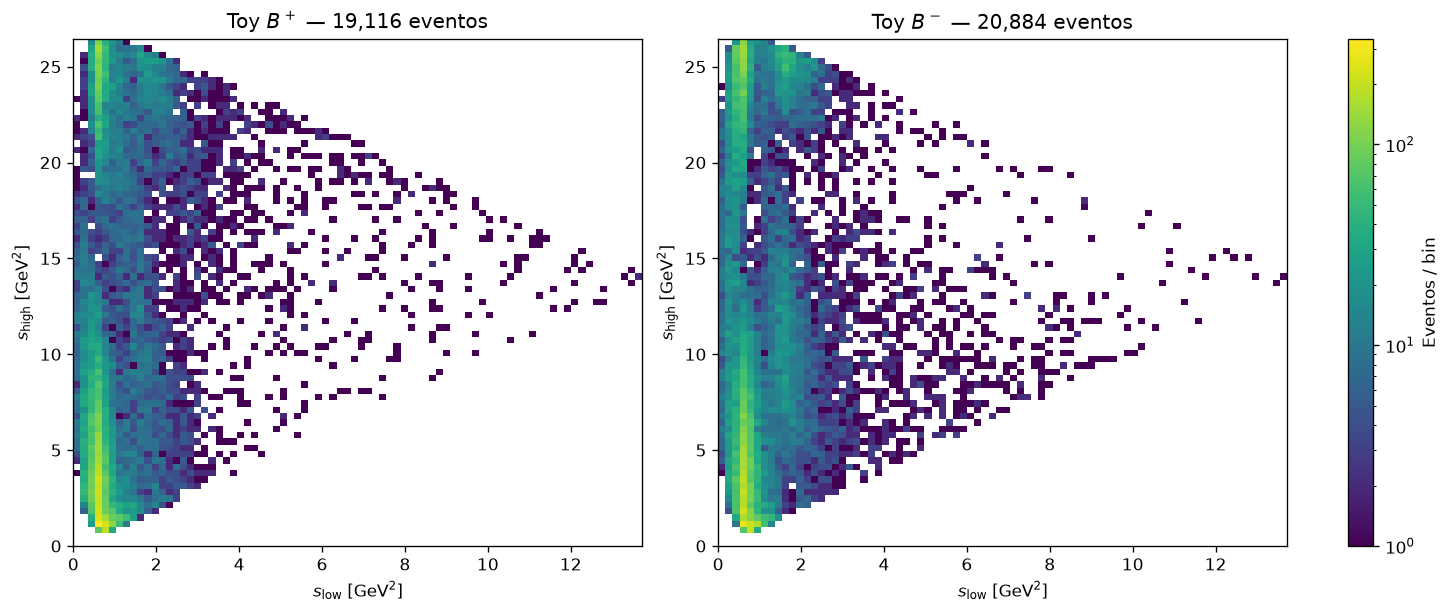

In [13]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

PROJECTION_SIZE = 500_000
PROJECTION_SEED = 190905214
PROJECTION_BINS = 60

# Mesmos bins e escala de cores para comparar as duas cargas.
folded_coordinates = [
    (np.minimum(np.asarray(data.s13), np.asarray(data.s23)),
     np.maximum(np.asarray(data.s13), np.asarray(data.s23)))
    for data in (plus_toy, minus_toy)
]
xmax = max(float(x.max()) for x, y in folded_coordinates)
ymax = max(float(y.max()) for x, y in folded_coordinates)
edges_low = np.linspace(0, xmax * 1.001, 81)
edges_high = np.linspace(0, ymax * 1.001, 81)
counts = [np.histogram2d(x, y, bins=(edges_low, edges_high))[0]
          for x, y in folded_coordinates]
color_norm = LogNorm(vmin=1, vmax=max(float(h.max()) for h in counts))
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for ax, histogram, charge, data in zip(
    axes, counts, ("+", "-"), (plus_toy, minus_toy), strict=True
):
    mesh = ax.pcolormesh(edges_low, edges_high, np.ma.masked_less(histogram.T, 1),
                         norm=color_norm, cmap="viridis", shading="auto")
    ax.set(xlabel=r"$s_{\rm low}$ [GeV$^2$]", ylabel=r"$s_{\rm high}$ [GeV$^2$]",
           title=rf"Toy $B^{charge}$ — {data.size:,} eventos")
fig.colorbar(mesh, ax=axes, label="Eventos / bin")
plt.show()

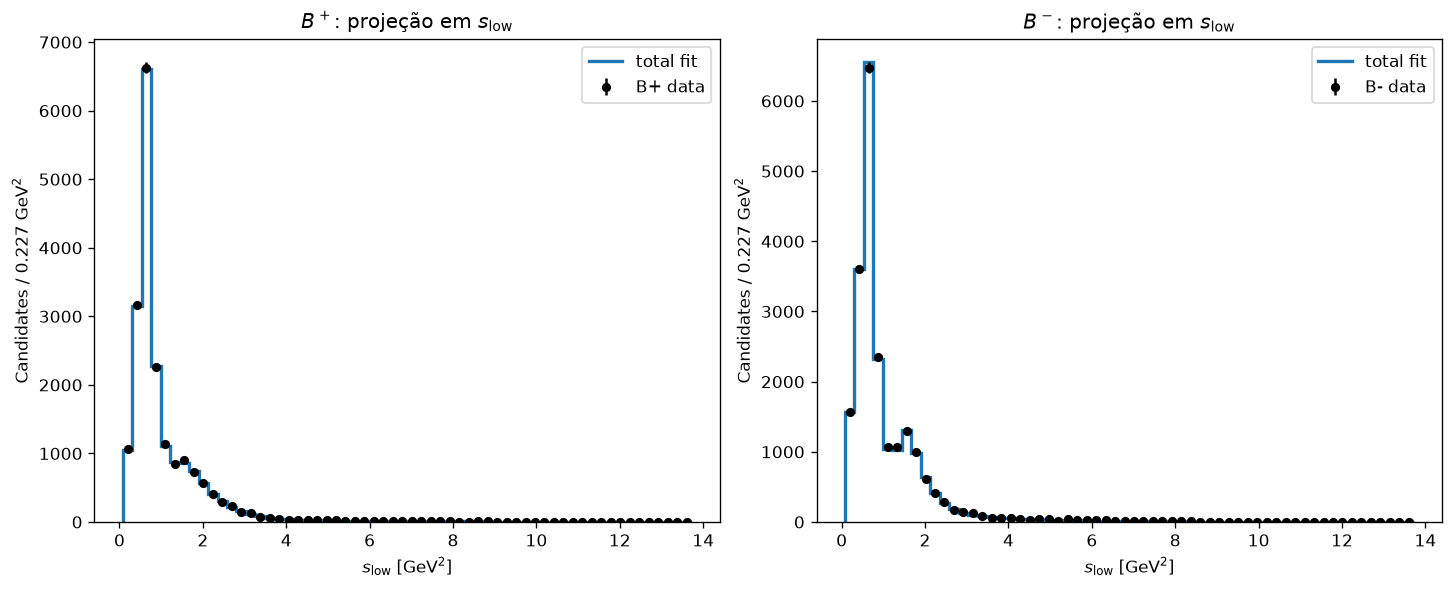

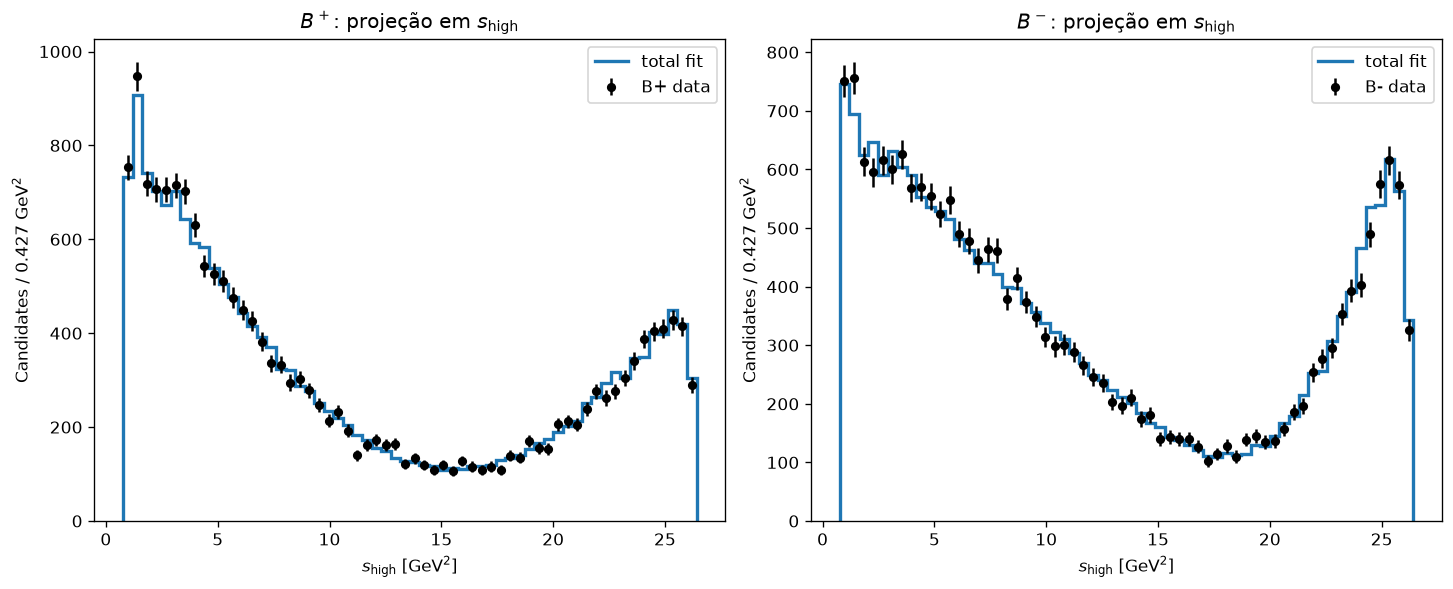

In [14]:
# Projeções dobradas: mantém a informação das duas combinações de massa.
for fold_side, label in (("low", "low"), ("high", "high")):
    axes = closure_session.plot_projection(
        closure_result, "s13", partner_variable="s23", folded=True,
        fold_side=fold_side, bins=PROJECTION_BINS, show_components=False,
        projection_size=PROJECTION_SIZE, projection_seed=PROJECTION_SEED,
    )
    for ax, charge in zip(axes, ("+", "-"), strict=True):
        ax.set_title(rf"$B^{charge}$: projeção em $s_{{\rm {label}}}$")
    plt.show()

### Zoom em $s_{\rm low}<4$ GeV$^2$

Projeções por carga com 80 bins entre 0 e 4 GeV$^2$ (largura de 0,05 GeV$^2$). A curva mantém a normalização conjunta do ajuste completo; o intervalo restringe apenas a projeção exibida.


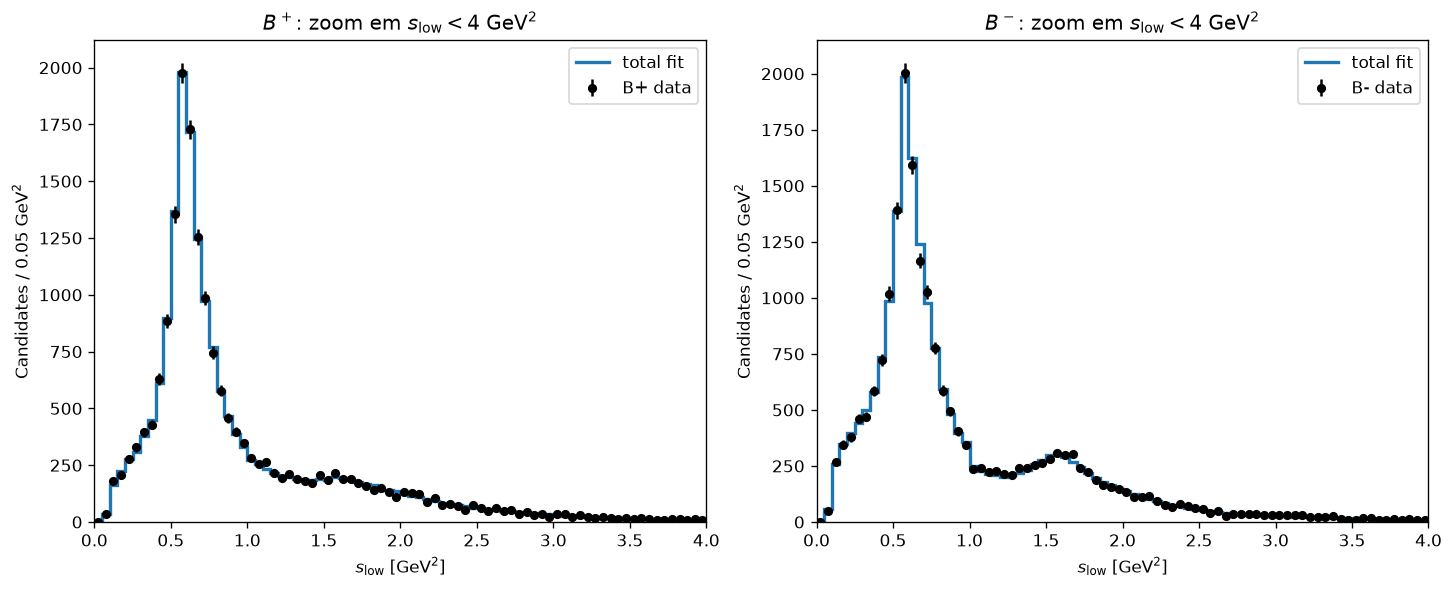

In [15]:
ZOOM_SLOW_RANGE = (0.0, 4.0)
ZOOM_SLOW_BINS = 80
zoom_axes = closure_session.plot_projection(
    closure_result, "s13", partner_variable="s23", folded=True,
    fold_side="low", bins=ZOOM_SLOW_BINS, range=ZOOM_SLOW_RANGE,
    show_components=False, projection_size=PROJECTION_SIZE,
    projection_seed=PROJECTION_SEED,
)
for ax, charge in zip(zoom_axes, ("+", "-"), strict=True):
    ax.set_xlim(*ZOOM_SLOW_RANGE)
    ax.set_title(rf"$B^{charge}$: zoom em $s_{{\rm low}}<4$ GeV$^2$")
plt.show()


### Recuperação dos coeficientes e de $A_{CP}$

As faixas no gráfico de pulls indicam $\pm1$ e $\pm2$ desvios padrão. Os 25 pulls vêm do mesmo pseudoexperimento e podem ser correlacionados. O gráfico de $A_{CP}$ usa as incertezas propagadas com a covariância completa do ajuste.

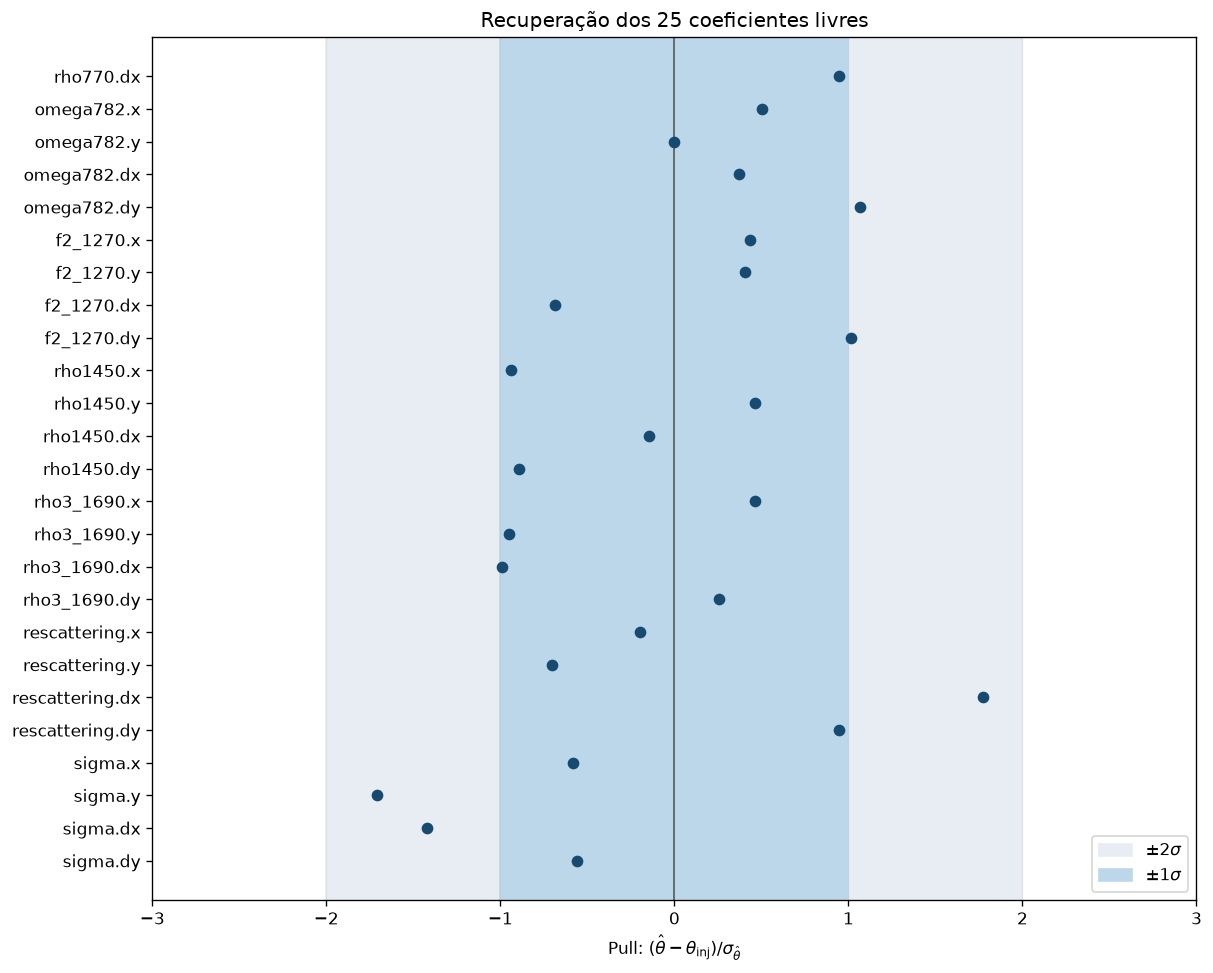

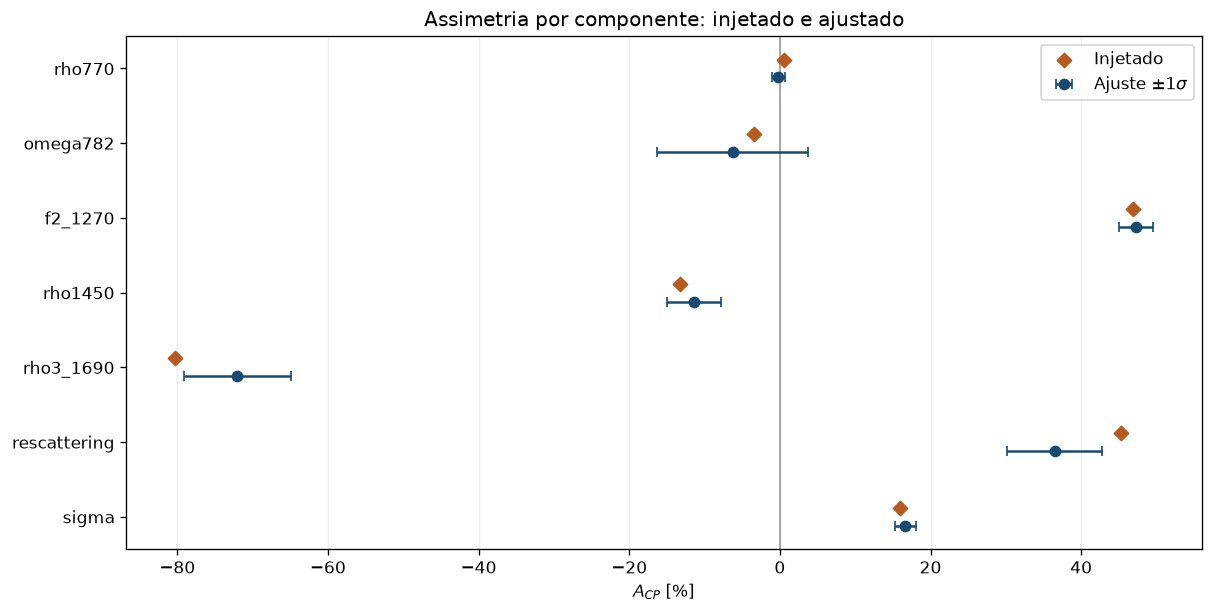

In [16]:
fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)
positions = np.arange(len(closure_coefficients))
ax.axvspan(-2, 2, color="#e7edf3", label=r"$\pm2\sigma$")
ax.axvspan(-1, 1, color="#bdd7ea", label=r"$\pm1\sigma$")
ax.axvline(0, color="0.35", linewidth=1)
ax.scatter(closure_coefficients["pull"], positions, color="#174a70", zorder=3)
ax.set_yticks(positions, closure_coefficients.index)
ax.invert_yaxis()
limit = max(3.0, float(closure_coefficients["pull"].abs().max()) + 0.4)
ax.set(xlim=(-limit, limit), xlabel=r"Pull: $(\hat\theta-\theta_{\rm inj})/\sigma_{\hat\theta}$",
       title="Recuperação dos 25 coeficientes livres")
ax.grid(axis="x", alpha=0.2)
ax.legend(loc="lower right")
plt.show()

acp_rows = closure_observable_table.loc[
    [f"ACP {name} [%]" for name in COEFFICIENTS]
]
positions = np.arange(len(acp_rows))
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
ax.axvline(0, color="0.6", linewidth=1)
ax.scatter(acp_rows["injected"], positions - 0.12, marker="D", color="#b65b20",
           label="Injetado", zorder=3)
ax.errorbar(acp_rows["fit"], positions + 0.12, xerr=acp_rows["error"],
            fmt="o", capsize=3, color="#174a70", label=r"Ajuste $\pm1\sigma$")
ax.set_yticks(positions, list(COEFFICIENTS))
ax.invert_yaxis()
ax.set(xlabel=r"$A_{CP}$ [%]", title="Assimetria por componente: injetado e ajustado")
ax.grid(axis="x", alpha=0.2)
ax.legend()
plt.show()